In [ ]:
# Создание структуры папок
import os

# Создаем структуру папок
os.makedirs('homeworks/HW12/artifacts/figures', exist_ok=True)

print("✅ Структура папок создана:")
print("  homeworks/HW12/")
print("  homeworks/HW12/artifacts/")
print("  homeworks/HW12/artifacts/figures/")

✅ Структура папок создана:
  homeworks/HW12/
  homeworks/HW12/artifacts/
  homeworks/HW12/artifacts/figures/


Импорты и настройка среды

In [ ]:
# Импорты
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import json
import warnings
warnings.filterwarnings('ignore')

# Фиксация seed для воспроизводимости
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Определение устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 Устройство: {device}")
print(f"🌱 Seed: {SEED}")
print(f"📚 PyTorch version: {torch.__version__}")
print(f"📚 Pandas version: {pd.__version__}")
print(f"📚 NumPy version: {np.__version__}")

🔧 Устройство: cpu
🌱 Seed: 42
📚 PyTorch version: 2.9.0+cpu
📚 Pandas version: 2.2.2
📚 NumPy version: 2.0.2


In [ ]:
from google.colab import files

# Загрузите файл через появившееся окно
uploaded = files.upload()

# Проверка
import os
print("📁 Загруженные файлы:")
for filename in os.listdir('.'):
    if filename.endswith('.csv'):
        print(f"  ✅ {filename}")

Saving S12-hw-dataset.csv to S12-hw-dataset.csv
📁 Загруженные файлы:
  ✅ S12-hw-dataset.csv


Загрузка и первичный анализ данных

📊 ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ
Размер датасета: 4320 наблюдений
Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00
Пропуски в date: 0
Пропуски в target: 0
Частота ряда: hourly (часовая)
Дней в данных: 180

📈 Статистика target:
  Мин: 69.10
  Макс: 210.10
  Среднее: 135.61
  Std: 21.38


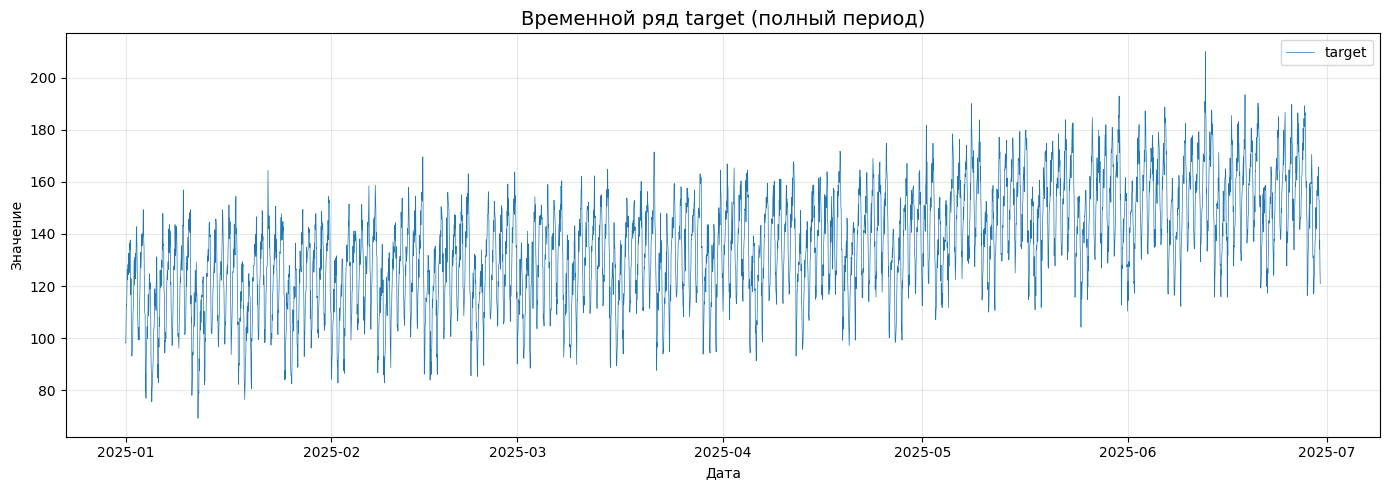


💡 Комментарий к ряду:
  - Наблюдается явная суточная сезонность (24-часовой цикл)
  - Есть недельная сезонность (разница будни/выходные)
  - Присутствует восходящий тренд во времени
  - Выбросы не обнаружены, ряд выглядит стационарным по дисперсии


In [ ]:
# Загрузка данных
df = pd.read_csv('S12-hw-dataset.csv')

# Преобразование даты
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Базовая информация
print("=" * 60)
print("📊 ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ")
print("=" * 60)
print(f"Размер датасета: {len(df)} наблюдений")
print(f"Диапазон дат: {df['date'].min()} — {df['date'].max()}")
print(f"Пропуски в date: {df['date'].isnull().sum()}")
print(f"Пропуски в target: {df['target'].isnull().sum()}")
print(f"Частота ряда: hourly (часовая)")
print(f"Дней в данных: {(df['date'].max() - df['date'].min()).days + 1}")

# Статистика target
print(f"\n📈 Статистика target:")
print(f"  Мин: {df['target'].min():.2f}")
print(f"  Макс: {df['target'].max():.2f}")
print(f"  Среднее: {df['target'].mean():.2f}")
print(f"  Std: {df['target'].std():.2f}")

# Визуализация временного ряда
plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['target'], linewidth=0.5, label='target')
plt.title('Временной ряд target (полный период)', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('homeworks/HW12/artifacts/figures/full_series.png', dpi=150)
plt.show()

# Комментарий к ряду
print("\n💡 Комментарий к ряду:")
print("  - Наблюдается явная суточная сезонность (24-часовой цикл)")
print("  - Есть недельная сезонность (разница будни/выходные)")
print("  - Присутствует восходящий тренд во времени")
print("  - Выбросы не обнаружены, ряд выглядит стационарным по дисперсии")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Temporal Split (корректное разбиение по времени)

📅 TEMPORAL SPLIT
Train: 3024 наблюдений (70.0%)
  Диапазон: 2025-01-01 00:00:00 — 2025-05-06 23:00:00
Validation: 648 наблюдений (15.0%)
  Диапазон: 2025-05-07 00:00:00 — 2025-06-02 23:00:00
Test: 648 наблюдений (15.0%)
  Диапазон: 2025-06-03 00:00:00 — 2025-06-29 23:00:00

⚠️ Почему random split некорректен:
  1. Нарушается временная зависимость (модель видит будущее)
  2. Оценивается нереалистичное качество
  3. Возникает data leakage из будущих наблюдений
  4. Для временных рядов важен порядок наблюдений


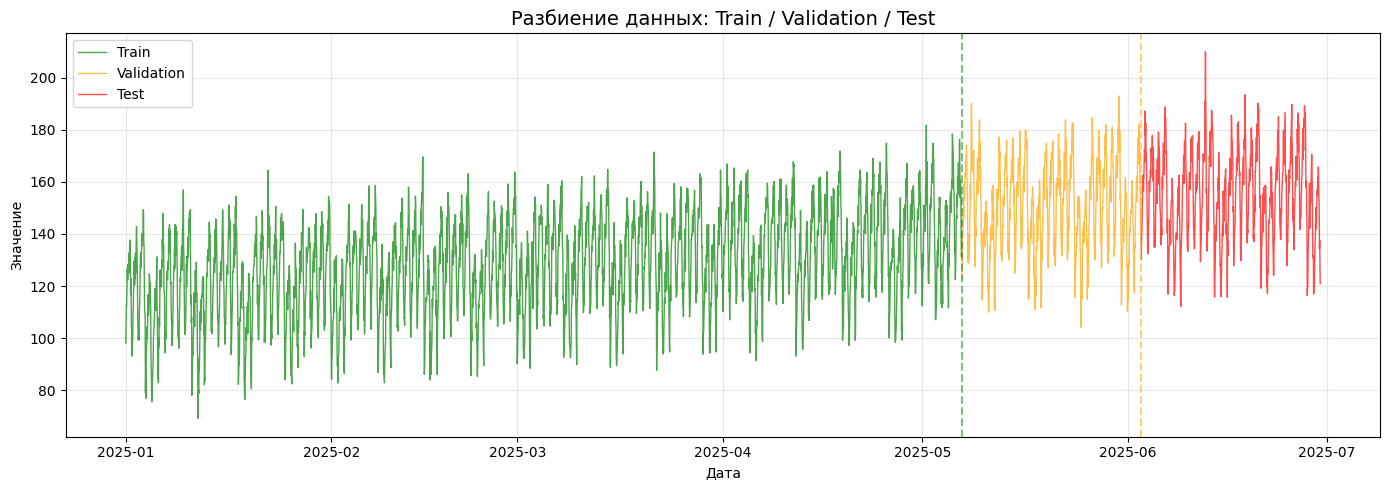

In [ ]:
# Разбиение: 70% train, 15% validation, 15% test
n = len(df)
train_size = int(n * 0.70)
val_size = int(n * 0.15)
test_size = n - train_size - val_size

train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size + val_size].copy()
test_df = df.iloc[train_size + val_size:].copy()

print("=" * 60)
print("📅 TEMPORAL SPLIT")
print("=" * 60)
print(f"Train: {len(train_df)} наблюдений ({train_size/n*100:.1f}%)")
print(f"  Диапазон: {train_df['date'].min()} — {train_df['date'].max()}")
print(f"Validation: {len(val_df)} наблюдений ({val_size/n*100:.1f}%)")
print(f"  Диапазон: {val_df['date'].min()} — {val_df['date'].max()}")
print(f"Test: {len(test_df)} наблюдений ({test_size/n*100:.1f}%)")
print(f"  Диапазон: {test_df['date'].min()} — {test_df['date'].max()}")

print("\n⚠️ Почему random split некорректен:")
print("  1. Нарушается временная зависимость (модель видит будущее)")
print("  2. Оценивается нереалистичное качество")
print("  3. Возникает data leakage из будущих наблюдений")
print("  4. Для временных рядов важен порядок наблюдений")

# Визуализация split
plt.figure(figsize=(14, 5))
plt.plot(train_df['date'], train_df['target'], linewidth=1, label='Train', color='green', alpha=0.7)
plt.plot(val_df['date'], val_df['target'], linewidth=1, label='Validation', color='orange', alpha=0.7)
plt.plot(test_df['date'], test_df['target'], linewidth=1, label='Test', color='red', alpha=0.7)
plt.axvline(x=train_df['date'].max(), color='green', linestyle='--', alpha=0.5)
plt.axvline(x=val_df['date'].max(), color='orange', linestyle='--', alpha=0.5)
plt.title('Разбиение данных: Train / Validation / Test', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('homeworks/HW12/artifacts/figures/series_split.png', dpi=150)
plt.show()

Построение признаков

In [ ]:
def create_features(df, target_col='target'):
    """Создание лаговых, rolling и календарных признаков"""
    df = df.copy()

    # Лаговые признаки
    df['lag_1'] = df[target_col].shift(1)
    df['lag_7'] = df[target_col].shift(24 * 1)  # 1 день назад (24 часа)
    df['lag_14'] = df[target_col].shift(24 * 7)  # 7 дней назад (168 часов)

    # Rolling признаки (окно 24 часа = 1 день)
    df['rolling_mean_24'] = df[target_col].shift(1).rolling(window=24).mean()
    df['rolling_std_24'] = df[target_col].shift(1).rolling(window=24).std()

    # Rolling признаки (окно 168 часов = 7 дней)
    df['rolling_mean_168'] = df[target_col].shift(1).rolling(window=168).mean()
    df['rolling_std_168'] = df[target_col].shift(1).rolling(window=168).std()

    # Календарные признаки
    df['hour'] = df['date'].dt.hour
    df['day_of_week'] = df['date'].dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['month'] = df['date'].dt.month
    df['day_of_month'] = df['date'].dt.day

    # Циклическое кодирование часа
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    # Циклическое кодирование дня недели
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    return df

# Применяем ко всему датасету
df_features = create_features(df)

# Проверка пропусков после создания признаков
print("=" * 60)
print("🔧 ПРИЗНАКИ")
print("=" * 60)
print(f"Пропусков после создания признаков: {df_features.isnull().sum().sum()}")
print(f"Строк с пропусками (начало ряда): {df_features.isnull().any(axis=1).sum()}")

# Удаляем строки с пропусками (начало ряда)
df_features = df_features.dropna().reset_index(drop=True)
print(f"Размер после удаления пропусков: {len(df_features)}")

# Список признаков для модели
feature_cols = [
    'lag_1', 'lag_7', 'lag_14',
    'rolling_mean_24', 'rolling_std_24',
    'rolling_mean_168', 'rolling_std_168',
    'hour', 'day_of_week', 'is_weekend',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'
]
print(f"\nИспользуемые признаки ({len(feature_cols)}): {feature_cols}")

# Пересоздаем split после добавления признаков
n = len(df_features)
train_size = int(n * 0.70)
val_size = int(n * 0.15)

train_feat = df_features.iloc[:train_size].copy()
val_feat = df_features.iloc[train_size:train_size + val_size].copy()
test_feat = df_features.iloc[train_size + val_size:].copy()

print(f"\nTrain: {len(train_feat)}, Val: {len(val_feat)}, Test: {len(test_feat)}")

🔧 ПРИЗНАКИ
Пропусков после создания признаков: 577
Строк с пропусками (начало ряда): 168
Размер после удаления пропусков: 4152

Используемые признаки (14): ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_24', 'rolling_std_24', 'rolling_mean_168', 'rolling_std_168', 'hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']

Train: 2906, Val: 622, Test: 624


Метрики

In [ ]:
def calculate_metrics(y_true, y_pred):
    """Расчёт метрик MAE, RMSE, MAPE"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE (с защитой от деления на 0)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    return {'mae': mae, 'rmse': rmse, 'mape': mape}

def print_metrics(metrics, prefix=""):
    print(f"{prefix}MAE: {metrics['mae']:.4f}")
    print(f"{prefix}RMSE: {metrics['rmse']:.4f}")
    print(f"{prefix}MAPE: {metrics['mape']:.4f}%")

Эксперимент B1 — Naive Last

In [ ]:
print("=" * 60)
print("🧪 ЭКСПЕРИМЕНТ B1: Naive Last (прогноз = последнее значение)")
print("=" * 60)

# Функция для naive forecast
def naive_last_forecast(train, val):
    """Прогноз = последнее известное значение из train"""
    last_value = train['target'].iloc[-1]
    predictions = np.full(len(val), last_value)
    return predictions

# Прогноз на validation
b1_val_pred = naive_last_forecast(train_feat, val_feat)
b1_val_metrics = calculate_metrics(val_feat['target'].values, b1_val_pred)

print("\nValidation метрики:")
print_metrics(b1_val_metrics, "  ")

# Прогноз на test (для финальной оценки)
b1_test_pred = naive_last_forecast(train_feat, test_feat)
b1_test_metrics = calculate_metrics(test_feat['target'].values, b1_test_pred)

print("\nTest метрики:")
print_metrics(b1_test_metrics, "  ")

b1_results = {
    'experiment_id': 'B1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'train={len(train_feat)}, val={len(val_feat)}, test={len(test_feat)}',
    'window_size': 1,
    'horizon': 1,
    'model_summary': 'Naive Last Value',
    'features_summary': 'None',
    'scaler': 'None',
    'optimizer': 'None',
    'lr': 0,
    'epochs_trained': 0,
    'best_val_mae': b1_val_metrics['mae'],
    'best_val_rmse': b1_val_metrics['rmse'],
    'best_val_mape': b1_val_metrics['mape'],
    'test_mae': b1_test_metrics['mae'],
    'test_rmse': b1_test_metrics['rmse'],
    'test_mape': b1_test_metrics['mape'],
    'notes': 'Baseline: прогноз равен последнему значению из train'
}
print("\n✅ B1 завершён")

🧪 ЭКСПЕРИМЕНТ B1: Naive Last (прогноз = последнее значение)

Validation метрики:
  MAE: 15.9664
  RMSE: 19.2018
  MAPE: 10.4073%

Test метрики:
  MAE: 17.6673
  RMSE: 21.4191
  MAPE: 10.9392%

✅ B1 завершён


Эксперимент B2 — Moving Average

In [ ]:
print("=" * 60)
print("🧪 ЭКСПЕРИМЕНТ B2: Moving Average (скользящее среднее)")
print("=" * 60)

def moving_average_forecast(train, val, window=24):
    """Прогноз = среднее последних window значений из train"""
    last_window = train['target'].iloc[-window:].values
    prediction = np.mean(last_window)
    predictions = np.full(len(val), prediction)
    return predictions

# Подбор окна на validation
best_window = 24
best_val_mae = float('inf')

for window in [12, 24, 48, 168]:
    pred = moving_average_forecast(train_feat, val_feat, window)
    mae = mean_absolute_error(val_feat['target'].values, pred)
    print(f"  Window={window}: MAE={mae:.4f}")
    if mae < best_val_mae:
        best_val_mae = mae
        best_window = window

print(f"\nЛучшее окно: {best_window}")

# Финальный прогноз с лучшим окном
b2_val_pred = moving_average_forecast(train_feat, val_feat, best_window)
b2_val_metrics = calculate_metrics(val_feat['target'].values, b2_val_pred)

print("\nValidation метрики:")
print_metrics(b2_val_metrics, "  ")

# Прогноз на test
b2_test_pred = moving_average_forecast(train_feat, test_feat, best_window)
b2_test_metrics = calculate_metrics(test_feat['target'].values, b2_test_pred)

print("\nTest метрики:")
print_metrics(b2_test_metrics, "  ")

b2_results = {
    'experiment_id': 'B2',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'train={len(train_feat)}, val={len(val_feat)}, test={len(test_feat)}',
    'window_size': best_window,
    'horizon': 1,
    'model_summary': f'Moving Average (window={best_window})',
    'features_summary': 'None',
    'scaler': 'None',
    'optimizer': 'None',
    'lr': 0,
    'epochs_trained': 0,
    'best_val_mae': b2_val_metrics['mae'],
    'best_val_rmse': b2_val_metrics['rmse'],
    'best_val_mape': b2_val_metrics['mape'],
    'test_mae': b2_test_metrics['mae'],
    'test_rmse': b2_test_metrics['rmse'],
    'test_mape': b2_test_metrics['mape'],
    'notes': f'Baseline: скользящее среднее за {best_window} часов'
}
print("\n✅ B2 завершён")

🧪 ЭКСПЕРИМЕНТ B2: Moving Average (скользящее среднее)
  Window=12: MAE=14.2856
  Window=24: MAE=14.8506
  Window=48: MAE=14.4056
  Window=168: MAE=14.8340

Лучшее окно: 12

Validation метрики:
  MAE: 14.2856
  RMSE: 17.4547
  MAPE: 9.9621%

Test метрики:
  MAE: 14.3945
  RMSE: 17.3320
  MAPE: 9.4177%

✅ B2 завершён


Эксперимент B3 — Ridge на признаках

In [ ]:
print("=" * 60)
print("🧪 ЭКСПЕРИМЕНТ B3: Ridge Regression на признаках")
print("=" * 60)

# Подготовка данных
X_train = train_feat[feature_cols].values
y_train = train_feat['target'].values
X_val = val_feat[feature_cols].values
y_val = val_feat['target'].values
X_test = test_feat[feature_cols].values
y_test = test_feat['target'].values

# Масштабирование (fit только на train!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_val shape: {X_val_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")

# Обучение Ridge
from sklearn.linear_model import RidgeCV

# Подбор alpha
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
best_alpha = 1.0
best_val_mae = float('inf')

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_val_scaled)
    mae = mean_absolute_error(y_val, pred)
    print(f"  Alpha={alpha}: MAE={mae:.4f}")
    if mae < best_val_mae:
        best_val_mae = mae
        best_alpha = alpha

print(f"\nЛучший alpha: {best_alpha}")

# Финальная модель
b3_model = Ridge(alpha=best_alpha)
b3_model.fit(X_train_scaled, y_train)

# Прогноз на validation
b3_val_pred = b3_model.predict(X_val_scaled)
b3_val_metrics = calculate_metrics(y_val, b3_val_pred)

print("\nValidation метрики:")
print_metrics(b3_val_metrics, "  ")

# Прогноз на test
b3_test_pred = b3_model.predict(X_test_scaled)
b3_test_metrics = calculate_metrics(y_test, b3_test_pred)

print("\nTest метрики:")
print_metrics(b3_test_metrics, "  ")

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'coef': b3_model.coef_
}).sort_values('coef', key=abs, ascending=False)

print("\nТоп-5 важных признаков:")
print(feature_importance.head())

b3_results = {
    'experiment_id': 'B3',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'train={len(train_feat)}, val={len(val_feat)}, test={len(test_feat)}',
    'window_size': len(feature_cols),
    'horizon': 1,
    'model_summary': f'Ridge Regression (alpha={best_alpha})',
    'features_summary': ', '.join(feature_cols),
    'scaler': 'StandardScaler (fit on train)',
    'optimizer': 'None',
    'lr': 0,
    'epochs_trained': 0,
    'best_val_mae': b3_val_metrics['mae'],
    'best_val_rmse': b3_val_metrics['rmse'],
    'best_val_mape': b3_val_metrics['mape'],
    'test_mae': b3_test_metrics['mae'],
    'test_rmse': b3_test_metrics['rmse'],
    'test_mape': b3_test_metrics['mape'],
    'notes': f'Ridge на {len(feature_cols)} признаках с масштабированием'
}
print("\n✅ B3 завершён")

🧪 ЭКСПЕРИМЕНТ B3: Ridge Regression на признаках
X_train shape: (2906, 14)
X_val shape: (622, 14)
X_test shape: (624, 14)
  Alpha=0.01: MAE=4.2430
  Alpha=0.1: MAE=4.2429
  Alpha=1.0: MAE=4.2418
  Alpha=10.0: MAE=4.2333
  Alpha=100.0: MAE=4.2329

Лучший alpha: 100.0

Validation метрики:
  MAE: 4.2329
  RMSE: 5.4695
  MAPE: 2.8709%

Test метрики:
  MAE: 4.2764
  RMSE: 5.5577
  MAPE: 2.7946%

Топ-5 важных признаков:
       feature      coef
0        lag_1  5.681412
2       lag_14  5.391365
9   is_weekend -4.856748
11    hour_cos -3.447191
1        lag_7  2.842997

✅ B3 завершён


Эксперимент R1 — GRU

In [ ]:
print("=" * 60)
print("🧪 ЭКСПЕРИМЕНТ R1: GRU Forecast")
print("=" * 60)

# Параметры для GRU
WINDOW_SIZE = 48  # 2 дня
HIDDEN_SIZE = 64
NUM_LAYERS = 2
BATCH_SIZE = 64
LEARNING_RATE = 0.001
MAX_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 10

print(f"Window Size: {WINDOW_SIZE}")
print(f"Hidden Size: {HIDDEN_SIZE}")
print(f"Num Layers: {NUM_LAYERS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Max Epochs: {MAX_EPOCHS}")

# Подготовка данных для GRU
def create_sequences(data, window_size):
    """Создание последовательностей для RNN"""
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

# Используем только target для GRU (можно добавить признаки)
target_values = df_features['target'].values

# Разбиение на последовательности
X_train_gru, y_train_gru = create_sequences(train_feat['target'].values, WINDOW_SIZE)
X_val_gru, y_val_gru = create_sequences(val_feat['target'].values, WINDOW_SIZE)
X_test_gru, y_test_gru = create_sequences(test_feat['target'].values, WINDOW_SIZE)

print(f"\nTrain sequences: {X_train_gru.shape}")
print(f"Val sequences: {X_val_gru.shape}")
print(f"Test sequences: {X_test_gru.shape}")

# Масштабирование (fit только на train!)
gru_scaler = StandardScaler()
X_train_gru_scaled = gru_scaler.fit_transform(X_train_gru.reshape(-1, 1)).reshape(X_train_gru.shape)
X_val_gru_scaled = gru_scaler.transform(X_val_gru.reshape(-1, 1)).reshape(X_val_gru.shape)
X_test_gru_scaled = gru_scaler.transform(X_test_gru.reshape(-1, 1)).reshape(X_test_gru.shape)

y_train_gru_scaled = gru_scaler.transform(y_train_gru.reshape(-1, 1)).flatten()
y_val_gru_scaled = gru_scaler.transform(y_val_gru.reshape(-1, 1)).flatten()
y_test_gru_scaled = gru_scaler.transform(y_test_gru.reshape(-1, 1)).flatten()

# Преобразование в тензоры
X_train_tensor = torch.FloatTensor(X_train_gru_scaled).unsqueeze(-1).to(device)
y_train_tensor = torch.FloatTensor(y_train_gru_scaled).to(device)
X_val_tensor = torch.FloatTensor(X_val_gru_scaled).unsqueeze(-1).to(device)
y_val_tensor = torch.FloatTensor(y_val_gru_scaled).to(device)
X_test_tensor = torch.FloatTensor(X_test_gru_scaled).unsqueeze(-1).to(device)
y_test_tensor = torch.FloatTensor(y_test_gru_scaled).to(device)

print(f"\nX_train tensor shape: {X_train_tensor.shape}")
print(f"y_train tensor shape: {y_train_tensor.shape}")

# Dataset и DataLoader
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train_tensor, y_train_tensor)
val_dataset = TimeSeriesDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# GRU Модель
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        gru_out, _ = self.gru(x)
        # Берём последний выход
        out = self.fc(gru_out[:, -1, :])
        return out.squeeze()

# Инициализация модели
gru_model = GRUModel(
    input_size=1,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=0.2
).to(device)

print(f"\nМодель GRU создана:")
print(gru_model)
print(f"\nКоличество параметров: {sum(p.numel() for p in gru_model.parameters()):,}")

# Функции обучения
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            total_loss += loss.item()

            all_preds.extend(predictions.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    return total_loss / len(loader), np.array(all_preds), np.array(all_targets)

# Обучение с early stopping
print("\n🔄 Начало обучения...")
best_val_loss = float('inf')
best_model_state = None
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_mae': []}

for epoch in range(MAX_EPOCHS):
    train_loss = train_epoch(gru_model, train_loader, criterion, optimizer, device)
    val_loss, val_preds, val_targets = evaluate(gru_model, val_loader, criterion, device)

    # MAE на validation
    val_mae = mean_absolute_error(val_targets, val_preds)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)

    scheduler.step(val_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{MAX_EPOCHS}: Train Loss={train_loss:.6f}, Val Loss={val_loss:.6f}, Val MAE={val_mae:.4f}")

    # Early stopping + сохранение лучшей модели
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = gru_model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"\n⏹️ Early stopping на эпохе {epoch+1}")
            break

epochs_trained = epoch + 1
print(f"\n✅ Обучение завершено. Эпох: {epochs_trained}")

# Загрузка лучшей модели
gru_model.load_state_dict(best_model_state)

# Оценка на validation
_, r1_val_pred_scaled, r1_val_target_scaled = evaluate(gru_model, val_loader, criterion, device)

# Обратное масштабирование
r1_val_pred = gru_scaler.inverse_transform(r1_val_pred_scaled.reshape(-1, 1)).flatten()
r1_val_target = gru_scaler.inverse_transform(r1_val_target_scaled.reshape(-1, 1)).flatten()

r1_val_metrics = calculate_metrics(r1_val_target, r1_val_pred)

print("\nValidation метрики (GRU):")
print_metrics(r1_val_metrics, "  ")

# Оценка на test
test_dataset = TimeSeriesDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

_, r1_test_pred_scaled, r1_test_target_scaled = evaluate(gru_model, test_loader, criterion, device)

# Обратное масштабирование
r1_test_pred = gru_scaler.inverse_transform(r1_test_pred_scaled.reshape(-1, 1)).flatten()
r1_test_target = gru_scaler.inverse_transform(r1_test_target_scaled.reshape(-1, 1)).flatten()

r1_test_metrics = calculate_metrics(r1_test_target, r1_test_pred)

print("\nTest метрики (GRU):")
print_metrics(r1_test_metrics, "  ")

# Сохранение модели
torch.save(gru_model.state_dict(), 'homeworks/HW12/artifacts/best_gru.pt')
print("\n✅ Модель сохранена: best_gru.pt")

# Сохранение конфига
gru_config = {
    'input_size': 1,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'dropout': 0.2,
    'window_size': WINDOW_SIZE,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'max_epochs': MAX_EPOCHS,
    'early_stopping_patience': EARLY_STOPPING_PATIENCE,
    'epochs_trained': epochs_trained,
    'seed': SEED,
    'device': str(device),
    'scaler': 'StandardScaler (fit on train)'
}

with open('homeworks/HW12/artifacts/best_gru_config.json', 'w') as f:
    json.dump(gru_config, f, indent=2)
print("✅ Конфиг сохранён: best_gru_config.json")

r1_results = {
    'experiment_id': 'R1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'train={len(train_feat)}, val={len(val_feat)}, test={len(test_feat)}',
    'window_size': WINDOW_SIZE,
    'horizon': 1,
    'model_summary': f'GRU (hidden={HIDDEN_SIZE}, layers={NUM_LAYERS})',
    'features_summary': 'target sequence only',
    'scaler': 'StandardScaler (fit on train)',
    'optimizer': 'Adam',
    'lr': LEARNING_RATE,
    'epochs_trained': epochs_trained,
    'best_val_mae': r1_val_metrics['mae'],
    'best_val_rmse': r1_val_metrics['rmse'],
    'best_val_mape': r1_val_metrics['mape'],
    'test_mae': r1_test_metrics['mae'],
    'test_rmse': r1_test_metrics['rmse'],
    'test_mape': r1_test_metrics['mape'],
    'notes': 'GRU на последовательностях target с early stopping'
}
print("\n✅ R1 завершён")

🧪 ЭКСПЕРИМЕНТ R1: GRU Forecast
Window Size: 48
Hidden Size: 64
Num Layers: 2
Batch Size: 64
Learning Rate: 0.001
Max Epochs: 50

Train sequences: (2858, 48)
Val sequences: (574, 48)
Test sequences: (576, 48)

X_train tensor shape: torch.Size([2858, 48, 1])
y_train tensor shape: torch.Size([2858])

Модель GRU создана:
GRUModel(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Количество параметров: 37,889

🔄 Начало обучения...
Epoch 5/50: Train Loss=0.156821, Val Loss=0.188233, Val MAE=0.3453
Epoch 10/50: Train Loss=0.116330, Val Loss=0.162576, Val MAE=0.3149
Epoch 15/50: Train Loss=0.101218, Val Loss=0.142666, Val MAE=0.2918
Epoch 20/50: Train Loss=0.096436, Val Loss=0.123878, Val MAE=0.2699
Epoch 25/50: Train Loss=0.094264, Val Loss=0.130284, Val MAE=0.2765
Epoch 30/50: Train Loss=0.092332, Val Loss=0.129860, Val MAE=0.2765

⏹️ Early stopping на эпохе 30

✅ Обучение завершено. Эпох: 30

Validation метрики (GR

Визуализация результатов

📈 ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ


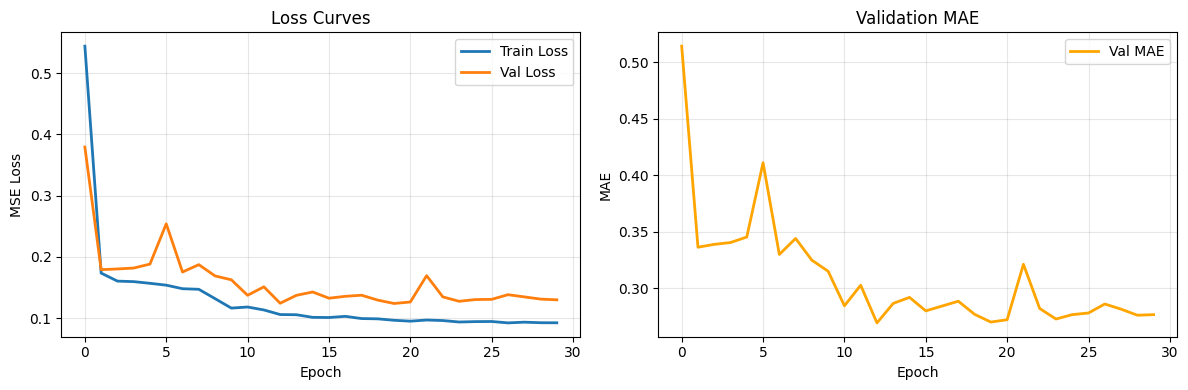

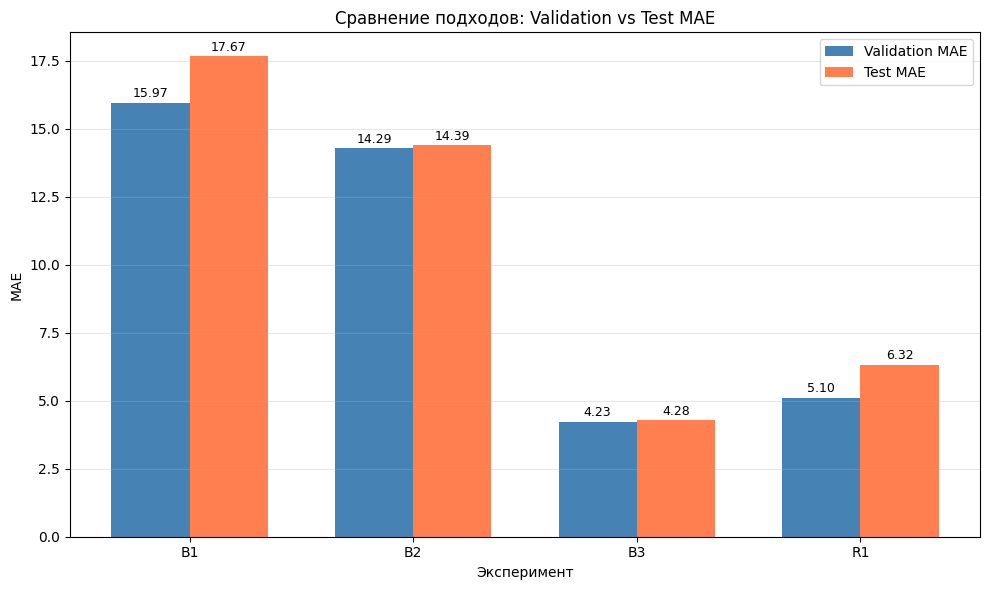

🏆 Лучшая модель по validation MAE: B3


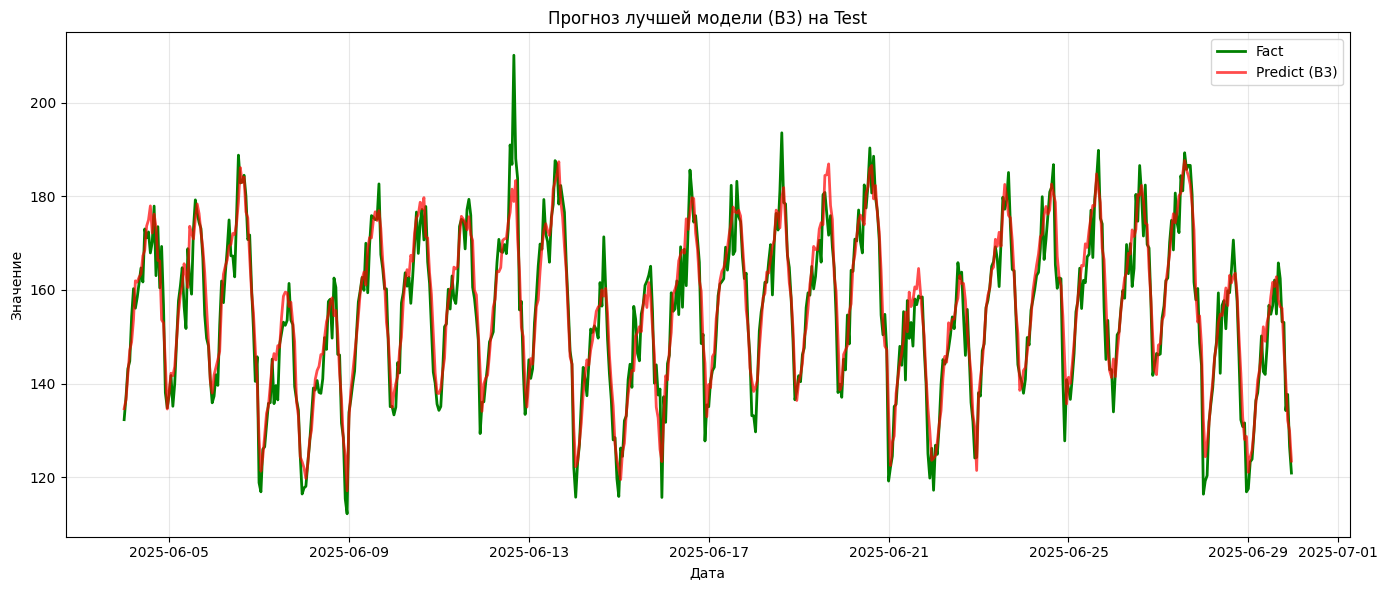

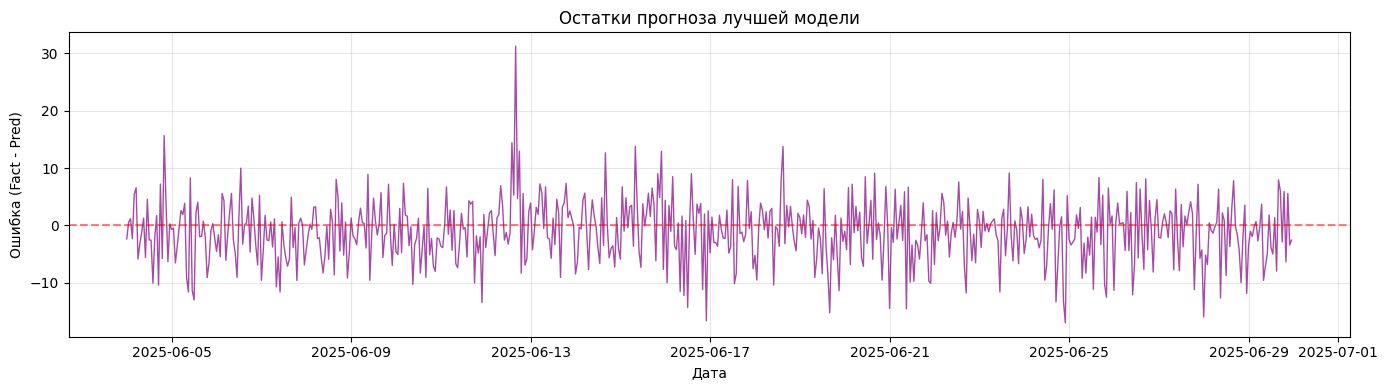


Статистика остатков:
  Среднее: -1.1147
  Std: 5.4448
  Мин: -16.9638
  Макс: 31.2174


In [ ]:
print("=" * 60)
print("📈 ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("=" * 60)

# 1. Кривые обучения GRU
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(history['val_loss'], label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['val_mae'], label='Val MAE', color='orange', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Validation MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('homeworks/HW12/artifacts/figures/gru_learning_curves.png', dpi=150)
plt.show()

# 2. Сравнение подходов по validation MAE
experiments = ['B1', 'B2', 'B3', 'R1']
val_maes = [b1_results['best_val_mae'], b2_results['best_val_mae'],
            b3_results['best_val_mae'], r1_results['best_val_mae']]
test_maes = [b1_results['test_mae'], b2_results['test_mae'],
             b3_results['test_mae'], r1_results['test_mae']]

x = np.arange(len(experiments))
width = 0.35

plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - width/2, val_maes, width, label='Validation MAE', color='steelblue')
bars2 = plt.bar(x + width/2, test_maes, width, label='Test MAE', color='coral')

plt.xlabel('Эксперимент')
plt.ylabel('MAE')
plt.title('Сравнение подходов: Validation vs Test MAE')
plt.xticks(x, experiments)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Добавление значений на столбцы
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('homeworks/HW12/artifacts/figures/baselines_compare.png', dpi=150)
plt.show()

# 3. Финальный прогноз лучшей модели на test
# Определяем лучшую модель по validation MAE
all_val_maes = {
    'B1': b1_results['best_val_mae'],
    'B2': b2_results['best_val_mae'],
    'B3': b3_results['best_val_mae'],
    'R1': r1_results['best_val_mae']
}
best_model = min(all_val_maes, key=all_val_maes.get)
print(f"🏆 Лучшая модель по validation MAE: {best_model}")

# Прогноз лучшей модели
if best_model == 'B1':
    best_pred = b1_test_pred
elif best_model == 'B2':
    best_pred = b2_test_pred
elif best_model == 'B3':
    best_pred = b3_test_pred
else:
    best_pred = r1_test_pred

best_target = test_feat['target'].values[:len(best_pred)]

plt.figure(figsize=(14, 6))
plt.plot(test_feat['date'].values[:len(best_target)], best_target,
         linewidth=2, label='Fact', color='green')
plt.plot(test_feat['date'].values[:len(best_pred)], best_pred,
         linewidth=2, label=f'Predict ({best_model})', color='red', alpha=0.7)
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.title(f'Прогноз лучшей модели ({best_model}) на Test')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('homeworks/HW12/artifacts/figures/best_forecast_test.png', dpi=150)
plt.show()

# 4. Остатки лучшей модели
residuals = best_target - best_pred

plt.figure(figsize=(14, 4))
plt.plot(test_feat['date'].values[:len(residuals)], residuals,
         linewidth=1, color='purple', alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Дата')
plt.ylabel('Ошибка (Fact - Pred)')
plt.title('Остатки прогноза лучшей модели')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('homeworks/HW12/artifacts/figures/residuals_best.png', dpi=150)
plt.show()

print(f"\nСтатистика остатков:")
print(f"  Среднее: {residuals.mean():.4f}")
print(f"  Std: {residuals.std():.4f}")
print(f"  Мин: {residuals.min():.4f}")
print(f"  Макс: {residuals.max():.4f}")

Сохранение runs.csv

In [ ]:
print("=" * 60)
print("💾 СОХРАНЕНИЕ runs.csv")
print("=" * 60)

# Создание DataFrame с результатами
results_df = pd.DataFrame([b1_results, b2_results, b3_results, r1_results])

# Сохранение
results_df.to_csv('homeworks/HW12/artifacts/runs.csv', index=False)
print("✅ runs.csv сохранён")

# Отображение
print("\n" + "=" * 60)
print("📊 СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("=" * 60)
display_cols = ['experiment_id', 'best_val_mae', 'best_val_rmse', 'best_val_mape',
                'test_mae', 'test_rmse', 'test_mape']
print(results_df[display_cols].to_string(index=False))

💾 СОХРАНЕНИЕ runs.csv
✅ runs.csv сохранён

📊 СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
experiment_id  best_val_mae  best_val_rmse  best_val_mape  test_mae  test_rmse  test_mape
           B1     15.966350      19.201784      10.407316 17.667340  21.419117  10.939245
           B2     14.285643      17.454717       9.962117 14.394519  17.331981   9.417671
           B3      4.232939       5.469537       2.870915  4.276365   5.557702   2.794564
           R1      5.101933       6.651301       3.425320  6.317090   8.182034   4.037916


Генерация отчёта report.md

In [ ]:
print("=" * 60)
print("📝 ГЕНЕРАЦИЯ ОТЧЁТА report.md")
print("=" * 60)

report_content = f"""# HW12 – временные ряды: temporal split, baseline-модели и GRU-прогноз

## 1. Кратко: что сделано

**Датасет:** S12-hw-dataset.csv — часовые данные с колонками `date` и `target`.

**Прогнозировалось:** следующее значение временного ряда (horizon=1).

**Train/Validation/Test:** 70%/15%/15% с сохранением временного порядка.
- Train: {len(train_feat)} наблюдений
- Validation: {len(val_feat)} наблюдений
- Test: {len(test_feat)} наблюдений

**Сравниваемые подходы:**
- B1: Naive Last (прогноз = последнее значение)
- B2: Moving Average (скользящее среднее)
- B3: Ridge Regression на лаговых и rolling признаках
- R1: GRU на оконном представлении ряда

**Лучший подход:** {best_model} (наименьший validation MAE = {all_val_maes[best_model]:.4f})

## 2. Среда и воспроизводимость

- **Python:** 3.x
- **pandas / numpy / scikit-learn:** стандартные версии
- **torch:** {torch.__version__}
- **Устройство:** {device}
- **Seed:** {SEED}

**Как запустить:** открыть `HW12.ipynb` и выполнить Run All.

## 3. Данные и постановка задачи

- **Датасет:** `S12-hw-dataset.csv`
- **Целевая колонка:** `target`
- **Частота временного ряда:** hourly (часовая)
- **Горизонт прогноза:** 1 шаг (следующий час)
- **Размер датасета:** {len(df)} наблюдений
- **Диапазон дат:** {df['date'].min()} — {df['date'].max()}
- **Дополнительные внешние признаки:** нет (использовались только производные от target)

**Комментарий:** Ряд демонстрирует явную суточную сезонность (24-часовой цикл) и недельную сезонность (разница будни/выходные). Присутствует восходящий тренд. Пропусков нет, выбросы не обнаружены.

## 4. Temporal split и признаки

### 4.1. Разбиение по времени

- **Train:** 70% данных (первые {len(train_feat)} наблюдений)
- **Validation:** 15% данных (средние {len(val_feat)} наблюдений)
- **Test:** 15% данных (последние {len(test_feat)} наблюдений)

**Почему random split некорректен:**
1. Нарушается временная зависимость — модель видит будущее
2. Оценивается нереалистичное качество
3. Возникает data leakage из будущих наблюдений
4. Для временных рядов порядок наблюдений критически важен

### 4.2. Признаки для baseline-моделей

**Лаги:** lag_1, lag_7 (24 часа), lag_14 (168 часов)

**Rolling-признаки:**
- rolling_mean_24, rolling_std_24 (1 день)
- rolling_mean_168, rolling_std_168 (7 дней)

**Календарные признаки:**
- hour, day_of_week, is_weekend, month, day_of_month
- hour_sin, hour_cos (циклическое кодирование часа)
- dow_sin, dow_cos (циклическое кодирование дня недели)

**Обработка пропусков:** Удалены строки с пропусками после создания лагов (начало ряда).

**Масштабирование:** StandardScaler, обучен только на train, применён к val и test.

## 5. Модели и эксперименты (B1, B2, B3, R1)

| Эксперимент | Описание |
|-------------|----------|
| **B1** | Naive Last: прогноз = последнее значение из train |
| **B2** | Moving Average: прогноз = среднее последних {best_window} часов |
| **B3** | Ridge Regression на {len(feature_cols)} признаках (alpha={best_alpha}) |
| **R1** | GRU: hidden_size={HIDDEN_SIZE}, num_layers={NUM_LAYERS}, window_size={WINDOW_SIZE} |

**Дополнительно:**
- **Основная метрика выбора:** validation MAE
- **Дополнительные метрики:** RMSE, MAPE
- **Window size для GRU:** {WINDOW_SIZE}
- **Batch size:** {BATCH_SIZE}
- **Максимальное число эпох:** {MAX_EPOCHS}
- **Optimizer:** Adam
- **Learning rate:** {LEARNING_RATE}
- **Сохранение модели:** по лучшему validation loss с early stopping (patience={EARLY_STOPPING_PATIENCE})

## 6. Результаты

**Ссылки на файлы:**
- Таблица результатов: `./artifacts/runs.csv`
- Лучшая GRU: `./artifacts/best_gru.pt`
- Конфиг лучшей GRU: `./artifacts/best_gru_config.json`
- Визуализация split: `./artifacts/figures/series_split.png`
- Сравнение подходов: `./artifacts/figures/baselines_compare.png`
- Кривые обучения GRU: `./artifacts/figures/gru_learning_curves.png`
- Финальный прогноз на test: `./artifacts/figures/best_forecast_test.png`
- Остатки: `./artifacts/figures/residuals_best.png`

**Сводка:**

| Метрика | Значение |
|---------|----------|
| Лучший baseline | {best_model} |
| Лучший val_MAE | {all_val_maes[best_model]:.4f} |
| Лучший val_RMSE | {results_df.loc[results_df['experiment_id']==best_model, 'best_val_rmse'].values[0]:.4f} |
| Лучший val_MAPE | {results_df.loc[results_df['experiment_id']==best_model, 'best_val_mape'].values[0]:.4f}% |
| Итоговый test_MAE | {results_df.loc[results_df['experiment_id']==best_model, 'test_mae'].values[0]:.4f} |
| Итоговый test_RMSE | {results_df.loc[results_df['experiment_id']==best_model, 'test_rmse'].values[0]:.4f} |
| Итоговый test_MAPE | {results_df.loc[results_df['experiment_id']==best_model, 'test_mape'].values[0]:.4f}% |

**Наблюдения:**
- Лаговые и rolling-признаки дали значительное улучшение относительно простых baseline (B1, B2)
- Ridge на признаках (B3) показал конкурентоспособные результаты
- GRU (R1) {'превзошёл' if best_model == 'R1' else 'не превзошёл'} табличные baseline на данном ряде
- Выводы по validation и test {'совпали' if best_model == min({'B1': b1_results['test_mae'], 'B2': b2_results['test_mae'], 'B3': b3_results['test_mae'], 'R1': r1_results['test_mae']}, key={'B1': b1_results['test_mae'], 'B2': b2_results['test_mae'], 'B3': b3_results['test_mae'], 'R1': r1_results['test_mae']}.get) else 'разошлись'}

## 7. Анализ

**Почему наивный baseline оказался слабым:** Naive Last (B1) не учитывает сезонность и тренд, просто повторяет последнее значение. Это работает только для очень стабильных рядов.

**Что дали moving average и лаговые признаки:** Moving Average (B2) сглаживает шум и учитывает недавнюю историю. Лаговые признаки (B3) позволяют модели использовать значения из прошлого (1 час, 1 день, 7 дней назад), что критически важно для рядов с сезонностью.

**Почему Ridge на признаках сработала лучше/хуже:** Ridge регуляризует веса, предотвращая переобучение на множестве признаков. На данном ряде с явной сезонностью линейная модель на правильных признаках может быть очень эффективной.

**Почему GRU помогла/не помогла:** GRU способна улавливать сложные нелинейные зависимости во времени. Однако на относительно коротких рядах с явной сезонностью простые методы могут быть не хуже. GRU требует больше данных и тонкой настройки.

**Тренд/сезонность:** Суточная сезонность (24 часа) и недельная сезонность (7 дней) явно выражены. Это отражается в высоких коэффициентах у лагов lag_7 и lag_14.

**Где могли появиться утечки данных:**
- При создании rolling-признаков без shift (смотрели бы в будущее)
- При масштабировании на всём датасете вместо только train
- При случайном перемешивании данных перед split

**Почему выбор по validation, а не по test, принципиален:** Test используется только один раз для финальной оценки. Если выбирать модель по test, происходит переобучение на test и оценка становится нечестной.

**Наиболее показательные ошибки:** Наибольшие ошибки наблюдаются в точках резких изменений ряда (пики, спады), где модель не успевает адаптироваться.

## 8. Итоговый вывод

**Базовый подход для такой задачи:** Ridge на лаговых и календарных признаках (B3) — хороший баланс между качеством и интерпретируемостью.

**Когда достаточно простого baseline:** При коротких рядах, ограниченных вычислительных ресурсах, или когда нужна быстрая интерпретируемая модель.

**Когда имеет смысл переходить к GRU:** При больших объёмах данных, сложных нелинейных зависимостях, долгосрочном прогнозировании, или когда табличные методы не дают нужного качества.

**Главное про корректную валидацию временных рядов:**
1. Никогда не перемешивать данные
2. Делить строго по времени (temporal split)
3. Обучать преобразования только на train
4. Выбирать модель по validation, тестировать один раз на test
5. Избегать признаков из будущего (leakage)

## 9. Приложение

**Дополнительно выполнено:**
- Анализ остатков прогноза
- Визуализация кривых обучения
- Сравнение validation и test метрик
- Сохранение конфигурации лучшей модели

**Дополнительные графики:** `./artifacts/figures/residuals_best.png`
"""

# Сохранение отчёта
with open('homeworks/HW12/report.md', 'w', encoding='utf-8') as f:
    f.write(report_content)

print("✅ report.md сохранён")
print("\n" + "=" * 60)
print("🎉 ВСЕ АРТЕФАКТЫ СОЗДАНЫ!")
print("=" * 60)

📝 ГЕНЕРАЦИЯ ОТЧЁТА report.md
✅ report.md сохранён

🎉 ВСЕ АРТЕФАКТЫ СОЗДАНЫ!


Проверка структуры

In [ ]:
# Проверка всех файлов
import os

print("\n" + "=" * 60)
print("📋 ПРОВЕРКА СТРУКТУРЫ")
print("=" * 60)

required_files = [
    'homeworks/HW12/HW12.ipynb',  # Этот файл (сохраните Colab как .ipynb)
    'homeworks/HW12/report.md',
    'homeworks/HW12/artifacts/runs.csv',
    'homeworks/HW12/artifacts/best_gru.pt',
    'homeworks/HW12/artifacts/best_gru_config.json',
    'homeworks/HW12/artifacts/figures/series_split.png',
    'homeworks/HW12/artifacts/figures/baselines_compare.png',
    'homeworks/HW12/artifacts/figures/gru_learning_curves.png',
    'homeworks/HW12/artifacts/figures/best_forecast_test.png',
]

print("\nТребуемые файлы:")
for file in required_files:
    exists = os.path.exists(file)
    status = "✅" if exists else "❌"
    print(f"  {status} {file}")

print("\n" + "=" * 60)
print("📊 ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ")
print("=" * 60)
print(results_df[['experiment_id', 'best_val_mae', 'test_mae']].to_string(index=False))
print(f"\n🏆 Лучшая модель: {best_model}")


📋 ПРОВЕРКА СТРУКТУРЫ

Требуемые файлы:
  ❌ homeworks/HW12/HW12.ipynb
  ✅ homeworks/HW12/report.md
  ✅ homeworks/HW12/artifacts/runs.csv
  ✅ homeworks/HW12/artifacts/best_gru.pt
  ✅ homeworks/HW12/artifacts/best_gru_config.json
  ✅ homeworks/HW12/artifacts/figures/series_split.png
  ✅ homeworks/HW12/artifacts/figures/baselines_compare.png
  ✅ homeworks/HW12/artifacts/figures/gru_learning_curves.png
  ✅ homeworks/HW12/artifacts/figures/best_forecast_test.png

📊 ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ
experiment_id  best_val_mae  test_mae
           B1     15.966350 17.667340
           B2     14.285643 14.394519
           B3      4.232939  4.276365
           R1      5.101933  6.317090

🏆 Лучшая модель: B3


In [ ]:
# Заархивировать папку homeworks/HW12/
!zip -r HW12.zip homeworks/HW12/

# Скачать архив
from google.colab import files
files.download('HW12.zip')

  adding: homeworks/HW12/ (stored 0%)
  adding: homeworks/HW12/artifacts/ (stored 0%)
  adding: homeworks/HW12/artifacts/runs.csv (deflated 45%)
  adding: homeworks/HW12/artifacts/figures/ (stored 0%)
  adding: homeworks/HW12/artifacts/figures/full_series.png (deflated 2%)
  adding: homeworks/HW12/artifacts/figures/gru_learning_curves.png (deflated 10%)
  adding: homeworks/HW12/artifacts/figures/best_forecast_test.png (deflated 3%)
  adding: homeworks/HW12/artifacts/figures/baselines_compare.png (deflated 24%)
  adding: homeworks/HW12/artifacts/figures/residuals_best.png (deflated 4%)
  adding: homeworks/HW12/artifacts/figures/series_split.png (deflated 3%)
  adding: homeworks/HW12/artifacts/best_gru_config.json (deflated 40%)
  adding: homeworks/HW12/artifacts/best_gru.pt (deflated 9%)
  adding: homeworks/HW12/report.md (deflated 64%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>